# Baseline: Euclidean Gradient Descent.

## Prepare Notebook.

### Import Libraries.

In [1]:
import math
import os
import sys
import yaml

import hydra
import numpy as np
import pandas as pd
import scanpy as sc
import seaborn as sns
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.decomposition import PCA
from tqdm import tqdm

sys.path.insert(0, "/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/collab-goettgens-SFC/shared_utils")
from experiment_utils import get_forward_model, generate_with_condition, generated_density_knn, get_adata_from_idx


In [2]:
color_map = {
    'HSCs': '#003049',
    'earlyMPP': '#023e8a',
    'MPP': '#005f73',
    'GMP-Neutro': '#0a9396',
    'GMP_cycling': '#1d3557',
    'MPP_MgkEry': '#264653',
    'MgKEryPro1': '#7f908f',
    'MgKEryPro2': '#4a5c6a',
    'MgkPro': '#3a4f6a',
    'late_MgkPro': '#3a4f6a',
    'EosBasMast1': '#6c757d',
    'EosBasMast2': '#780000',
    'EosBasMast3': '#9d0910',
    'EryPro': '#af0e18',
    'MLP': '#c1121f',
    'LMPP-CLP': '#ae2012',
    'preProB': '#9b2226',
    'ProB': '#df817a',
    'Pre-DC1': '#e76f51',
    'Pre-DC2': '#f4a261',
    'Early_GMP': '#ee9b00',
    'CD14Mono': '#fdf0d5',
    'CD16Mono': '#e9d8a6',
    'CyclingPro1': '#669bbc',
    'CyclingPro2': '#8ecae6',
}

In [3]:
config_path = "/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/collab-goettgens-SFC/inverse/loss_guidance/config/annotation/bloodplus.yaml"
with open(config_path, "r") as fb:
    annot_dict = yaml.safe_load(fb)
protocol_cols = annot_dict["protocol_columns"]

In [4]:
constraints_config_path = "/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/collab-goettgens-SFC/inverse/loss_guidance/config/constraints/default_all_cols.yaml"
with open(constraints_config_path, "r") as fb:
    constraints_config = yaml.safe_load(fb)
ubound_dict = constraints_config["ubound_dict"]
lbound_dict = constraints_config["lbound_dict"]


In [5]:
with hydra.initialize(
    config_path="../../config"
):
    config = hydra.compose(
        config_name="run_inverse_constrained",
        overrides=[
            "paths=bloodplus_fm",
            "annotation=bloodplus",
            "sampling.N=10",
            "sampling.num_time_steps=20",
            "forward_model.num_time_steps=20",
            "constraints=default_all_cols"
        ]
    )

/tmp/ipykernel_2539528/377118890.py:1: UserWarning: 
The version_base parameter is not specified.
Please specify a compatability version level, or None.
Will assume defaults for version 1.1
  with hydra.initialize(


In [6]:
path_adata_old = "/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/data/gdrive/new_dataset/BloodPlus_celltype_pm_500k_filtered_old_experiments_.h5ad"
adata_old = sc.read_h5ad(path_adata_old)
adata_old

AnnData object with n_obs × n_vars = 449218 × 20
    obs: 'experiment_number', 'replicate', 'date', 'cytometer', 'cytometer_serial_no', 'well_id', 'count_beads', 'cell_counts', 'experiment_id', '740-yp_[µm]', 'mtg_[µm]', 'rhflt3l_[ng_ml]', 'gm-csf_[ng_ml]', 'tpo_[ng_ml]', 'sr1_[nm]', 'um171_[nm]', 'um729_[µm]', 'scf_[ng_ml]', 'butyzamide_[nm]', 'retinoic_acid_[µm]', 'ldl_[ng_ml]', 'il3_[ng_ml]', 'source_id', 'hydrogel_type', 'o2_[%]', 'source_cell_phenotype', 'total_count_beads', 'counts_source_cell_phenotype', 'days_of_culture', 'plate', 'absolute_number_multiplier_[2^n]', 'cytometer_id', 'FSC-A :: FSC - Area', 'FSC-H :: FSC - Height', 'FSC-W :: FSC - Width', 'SSC-A :: SSC - Area', 'SSC-H :: SSC - Height', 'SSC-W :: SSC - Width', 'TIME', 'NA', 'AF Index', 'batch', '7-AAD', 'leiden', 'leiden_sub', 'leiden_old', 'cell_type'
    var: 'n', 'channel', 'marker', 'PnB', 'PnE', 'PnR', 'PnD', 'signal_type', 'antibody'
    uns: 'cell_type_colors', 'leiden', 'leiden_colors', 'leiden_colors_old',

In [7]:
path_adata_new = "/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/data/gdrive/new_dataset/BloodPlus_celltype_pm_500k_filtered_.h5ad"
adata_new = sc.read_h5ad(path_adata_new)
adata_new.uns["cell_type_colors"] = color_map
adata_new

AnnData object with n_obs × n_vars = 471836 × 20
    obs: 'experiment_number', 'replicate', 'date', 'cytometer', 'cytometer_serial_no', 'well_id', 'count_beads', 'cell_counts', 'experiment_id', '740-yp_[µm]', 'mtg_[µm]', 'rhflt3l_[ng_ml]', 'gm-csf_[ng_ml]', 'tpo_[ng_ml]', 'sr1_[nm]', 'um171_[nm]', 'um729_[µm]', 'scf_[ng_ml]', 'butyzamide_[nm]', 'retinoic_acid_[µm]', 'ldl_[ng_ml]', 'il3_[ng_ml]', 'source_id', 'hydrogel_type', 'o2_[%]', 'source_cell_phenotype', 'total_count_beads', 'counts_source_cell_phenotype', 'days_of_culture', 'plate', 'absolute_number_multiplier_[2^n]', 'cytometer_id', 'FSC-A :: FSC - Area', 'FSC-H :: FSC - Height', 'FSC-W :: FSC - Width', 'SSC-A :: SSC - Area', 'SSC-H :: SSC - Height', 'SSC-W :: SSC - Width', 'TIME', 'NA', 'AF Index', 'batch', '7-AAD', 'leiden', 'leiden_sub', 'leiden_old', 'cell_type'
    var: 'n', 'channel', 'marker', 'PnB', 'PnE', 'PnR', 'PnD', 'signal_type', 'antibody'
    uns: 'cell_type_colors', 'leiden', 'leiden_colors', 'leiden_colors_old',

In [8]:
path_adata_full_old = "/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/data/gdrive/new_dataset/BloodPlus_Logicle_pm_old_experiments_.h5ad"
adata_full_old = sc.read_h5ad(path_adata_full_old)
adata_full_old

AnnData object with n_obs × n_vars = 48189887 × 20
    obs: 'experiment_number', 'replicate', 'date', 'cytometer', 'cytometer_serial_no', 'well_id', 'count_beads', 'cell_counts', 'experiment_id', '740-yp_[µm]', 'mtg_[µm]', 'rhflt3l_[ng_ml]', 'gm-csf_[ng_ml]', 'tpo_[ng_ml]', 'sr1_[nm]', 'um171_[nm]', 'um729_[µm]', 'scf_[ng_ml]', 'butyzamide_[nm]', 'retinoic_acid_[µm]', 'ldl_[ng_ml]', 'il3_[ng_ml]', 'source_id', 'hydrogel_type', 'o2_[%]', 'source_cell_phenotype', 'total_count_beads', 'counts_source_cell_phenotype', 'days_of_culture', 'plate', 'absolute_number_multiplier_[2^n]', 'cytometer_id', 'FSC-A :: FSC - Area', 'FSC-H :: FSC - Height', 'FSC-W :: FSC - Width', 'SSC-A :: SSC - Area', 'SSC-H :: SSC - Height', 'SSC-W :: SSC - Width', 'TIME', 'NA', 'AF Index', 'batch', '7-AAD'
    var: 'n', 'channel', 'marker', 'PnB', 'PnE', 'PnR', 'PnD', 'signal_type', 'antibody'
    uns: 'meta', 'processing_steps'
    layers: 'positives', 'raw'

In [9]:
path_adata_full = "/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/data/gdrive/new_dataset/BloodPlus_Logicle_pm_.h5ad"
adata_full = sc.read_h5ad(path_adata_full)
adata_full

AnnData object with n_obs × n_vars = 52085765 × 20
    obs: 'experiment_number', 'replicate', 'date', 'cytometer', 'cytometer_serial_no', 'well_id', 'count_beads', 'cell_counts', 'experiment_id', '740-yp_[µm]', 'mtg_[µm]', 'rhflt3l_[ng_ml]', 'gm-csf_[ng_ml]', 'tpo_[ng_ml]', 'sr1_[nm]', 'um171_[nm]', 'um729_[µm]', 'scf_[ng_ml]', 'butyzamide_[nm]', 'retinoic_acid_[µm]', 'ldl_[ng_ml]', 'il3_[ng_ml]', 'source_id', 'hydrogel_type', 'o2_[%]', 'source_cell_phenotype', 'total_count_beads', 'counts_source_cell_phenotype', 'days_of_culture', 'plate', 'absolute_number_multiplier_[2^n]', 'cytometer_id', 'FSC-A :: FSC - Area', 'FSC-H :: FSC - Height', 'FSC-W :: FSC - Width', 'SSC-A :: SSC - Area', 'SSC-H :: SSC - Height', 'SSC-W :: SSC - Width', 'TIME', 'NA', 'AF Index', 'batch', '7-AAD'
    var: 'n', 'channel', 'marker', 'PnB', 'PnE', 'PnR', 'PnD', 'signal_type', 'antibody'
    uns: 'meta', 'processing_steps'
    layers: 'positives', 'raw'

In [10]:
# ----------------------------------------------------------------------
# Prepare unique real condition vectors (one per experiment)
# ----------------------------------------------------------------------
# Real condition vectors (assumed shape (n_cells, n_protocol))
real_conds = adata_full.obs[protocol_cols].astype(float).values   # or use obs[protocol_columns].values
exp_nums = adata_full.obs["experiment_number"].values

# Get unique condition per experiment
unique_exps = np.unique(exp_nums)
real_matrix = []
exp_labels = []
for exp in unique_exps:
    mask = exp_nums == exp
    cond = real_conds[mask][0]   # all cells in same exp share the same condition
    real_matrix.append(cond)
    exp_labels.append(exp)
real_matrix = np.array(real_matrix)   # (n_exp, n_protocol)
exp_labels = np.array(exp_labels)


In [11]:
candidates_base_dir = "/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/output/inverse/sgd/loop1"
schedulers = os.listdir(candidates_base_dir)

all_records = []
for sched in schedulers:
    sched_base_dir = os.path.join(
        candidates_base_dir, sched, "late_MgkPro"
    )

    runs_list = os.listdir(sched_base_dir)

    for run_id in runs_list:
        candidates_csv_path = os.path.join(sched_base_dir, run_id, "candidates.csv")
        # candidates_csv_path = os.path.join(sched_base_dir, run_id, "uncertainty_annotation", "candidates_with_uncertainties.csv")
        candidates_csv = pd.read_csv(candidates_csv_path)

        candidates_csv["run"] = run_id
        candidates_csv["sched"] = sched
        
        all_records.append(candidates_csv)
candidates_df = pd.concat(all_records, axis=0)
candidates_df

,sample_id,gm-csf_[ng_ml],tpo_[ng_ml],sr1_[nm],um171_[nm],um729_[µm],scf_[ng_ml],butyzamide_[nm],retinoic_acid_[µm],ldl_[ng_ml],...,cfg:scheduler:scheduler_kwargs:lambda_val,cfg:scheduler:scheduler_kwargs:lmin,cfg:scheduler:scheduler_kwargs:lmax,cfg:scheduler:scheduler_kwargs:gamma,cfg:optimized_metric,configuration path,inverse_results_path,fwd_results_path,run,sched
0,late_MgkPro:2026-06-03_03-00-45_da1ead49:0,4.591066,0.789268,3.929092,5.871652,0.0,0.000000,3.616932,13.556907,0.000000,...,NaN,NaN,1.00,0.99,all_conditions_wasserstein_distance,/lustre/groups/ml01/workspace/lorenzo.consoli/...,/lustre/groups/ml01/workspace/lorenzo.consoli/...,/lustre/groups/ml01/workspace/lorenzo.consoli/...,2026-06-03_03-00-45_da1ead49,exp-decay
1,late_MgkPro:2026-06-03_03-00-45_da1ead49:1,6.825718,27.505966,278.481750,1.707372,0.0,0.436186,0.000000,9.478207,1.982901,...,NaN,NaN,1.00,0.99,all_conditions_wasserstein_distance,/lustre/groups/ml01/workspace/lorenzo.consoli/...,/lustre/groups/ml01/workspace/lorenzo.consoli/...,/lustre/groups/ml01/workspace/lorenzo.consoli/...,2026-06-03_03-00-45_da1ead49,exp-decay
2,late_MgkPro:2026-06-03_03-00-45_da1ead49:2,0.000000,0.293584,18.132639,0.399798,0.0,15.701715,1.240126,1.057838,0.000000,...,NaN,NaN,1.00,0.99,all_conditions_wasserstein_distance,/lustre/groups/ml01/workspace/lorenzo.consoli/...,/lustre/groups/ml01/workspace/lorenzo.consoli/...,/lustre/groups/ml01/workspace/lorenzo.consoli/...,2026-06-03_03-00-45_da1ead49,exp-decay
3,late_MgkPro:2026-06-03_03-00-45_da1ead49:3,0.000000,0.000000,0.000000,15.733252,0.0,0.000000,6.184695,0.000000,0.000000,...,NaN,NaN,1.00,0.99,all_conditions_wasserstein_distance,/lustre/groups/ml01/workspace/lorenzo.consoli/...,/lustre/groups/ml01/workspace/lorenzo.consoli/...,/lustre/groups/ml01/workspace/lorenzo.consoli/...,2026-06-03_03-00-45_da1ead49,exp-decay
4,late_MgkPro:2026-06-03_03-00-45_da1ead49:4,3.440299,1.049867,3.387093,1.844777,0.0,0.000000,0.971715,14.640786,1.735316,...,NaN,NaN,1.00,0.99,all_conditions_wasserstein_distance,/lustre/groups/ml01/workspace/lorenzo.consoli/...,/lustre/groups/ml01/workspace/lorenzo.consoli/...,/lustre/groups/ml01/workspace/lorenzo.consoli/...,2026-06-03_03-00-45_da1ead49,exp-decay
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45,late_MgkPro:2026-06-02_19-02-01_3f4eb06f:45,0.325442,0.030783,53.601067,201.388720,0.0,15.257691,0.000000,0.000000,0.000000,...,NaN,NaN,0.01,NaN,all_conditions_wasserstein_distance,/lustre/groups/ml01/workspace/lorenzo.consoli/...,/lustre/groups/ml01/workspace/lorenzo.consoli/...,/lustre/groups/ml01/workspace/lorenzo.consoli/...,2026-06-02_19-02-01_3f4eb06f,lin-decay
46,late_MgkPro:2026-06-02_19-02-01_3f4eb06f:46,0.180418,0.993656,155.273480,77.226660,0.0,7.261713,0.000000,0.000000,0.000000,...,NaN,NaN,0.01,NaN,all_conditions_wasserstein_distance,/lustre/groups/ml01/workspace/lorenzo.consoli/...,/lustre/groups/ml01/workspace/lorenzo.consoli/...,/lustre/groups/ml01/workspace/lorenzo.consoli/...,2026-06-02_19-02-01_3f4eb06f,lin-decay
47,late_MgkPro:2026-06-02_19-02-01_3f4eb06f:47,1.569712,1.270321,206.699040,118.934970,0.0,10.546656,0.000000,0.000000,6.253183,...,NaN,NaN,0.01,NaN,all_conditions_wasserstein_distance,/lustre/groups/ml01/workspace/lorenzo.consoli/...,/lustre/groups/ml01/workspace/lorenzo.consoli/...,/lustre/groups/ml01/workspace/lorenzo.consoli/...,2026-06-02_19-02-01_3f4eb06f,lin-decay
48,late_MgkPro:2026-06-02_19-02-01_3f4eb06f:48,0.000000,0.075038,47.176310,92.453384,0.0,14.726857,0.000000,0.000000,0.000000,...,NaN,NaN,0.01,NaN,all_conditions_wasserstein_distance,/lustre/groups/ml01/workspace/lorenzo.consoli/...,/lustre/groups/ml01/workspace/lorenzo.consoli/...,/lustre/groups/ml01/workspace/lorenzo.consoli/...,2026-06-02_19-02-01_3f4eb06f,lin-decay


In [12]:
# ---- Define Margin for Filtering ----
margin = 0.1

# ----  Target Markers Loop ----
print("---- Filtering Results ----")
# define mask for all columns
marker_mask = np.full(candidates_df.shape[0], True)

# ----  Protocol Columns Loop ----
for col in protocol_cols:
    # get col bounds
    col_ubound = ubound_dict[col]
    col_lbound = lbound_dict[col]
    print(f"\t\t---- Processing Column {col} -> U: {col_ubound}, L: {col_lbound} ----")

    # get col values and mask
    col_values = candidates_df[col]
    col_mask_ubound_mask = col_values <= col_ubound*(1 + margin)
    col_mask_lbound_mask = col_values >= col_lbound*(1 - margin)

    # get masks for current column
    old_mask = marker_mask
    lbound_marker_mask = marker_mask & col_mask_lbound_mask
    ubound_marker_mask = marker_mask & col_mask_ubound_mask
    marker_mask = marker_mask & col_mask_ubound_mask & col_mask_lbound_mask

    # get number of solutions
    n_previously_accepted_solutions = old_mask.sum()
    n_accepted_solutions = marker_mask.sum()
    n_solutions_passing_ubound = col_mask_ubound_mask.sum()
    n_solutions_passing_lbound = col_mask_lbound_mask.sum()
    n_solutions_passing_ubound_and_previous_constraints = ubound_marker_mask.sum()
    n_solutions_passing_lbound_and_previous_constraints = lbound_marker_mask.sum()
    print(f"\t\t\t --- Number Previously Accepted Solutions {n_previously_accepted_solutions} ---")
    print(f"\t\t\t --- Number Currently Accepted Solutions {n_accepted_solutions} ---")
    print(f"\t\t\t --- Number of Solution Satisfying Upper Bound {n_solutions_passing_ubound} ---")
    print(f"\t\t\t --- Number of Solution Satisfying Lower Bound {n_solutions_passing_lbound} ---")
    print(f"\t\t\t --- Number of Solution Satisfying Upper Bound and Previous Constraints {n_solutions_passing_ubound_and_previous_constraints} ---")
    print(f"\t\t\t --- Number of Solution Satisfying Lower Bound and Previous Constraints {n_solutions_passing_lbound_and_previous_constraints} ---")


    # write values for constraint on current column
    candidates_df[f"passes_constraints:{col}:ubound"] = col_mask_ubound_mask
    candidates_df[f"passes_constraints:{col}:lbound"] = col_mask_ubound_mask

# write values for all constraints
n_all_solutions = candidates_df.shape[0]
n_accepted_solutions = marker_mask.sum()
candidates_df["passes_constraints:all"] = marker_mask

print(f"\t\t\t--- Finished, Out of {n_all_solutions} there are {n_accepted_solutions} Passing with Margin {margin} ----")

---- Filtering Results ----
		---- Processing Column gm-csf_[ng_ml] -> U: 10.0, L: 0.0 ----
			 --- Number Previously Accepted Solutions 20400 ---
			 --- Number Currently Accepted Solutions 18606 ---
			 --- Number of Solution Satisfying Upper Bound 18606 ---
			 --- Number of Solution Satisfying Lower Bound 19616 ---
			 --- Number of Solution Satisfying Upper Bound and Previous Constraints 18606 ---
			 --- Number of Solution Satisfying Lower Bound and Previous Constraints 19616 ---
		---- Processing Column tpo_[ng_ml] -> U: 2.5, L: 0.0 ----
			 --- Number Previously Accepted Solutions 18606 ---
			 --- Number Currently Accepted Solutions 17836 ---
			 --- Number of Solution Satisfying Upper Bound 18787 ---
			 --- Number of Solution Satisfying Lower Bound 19704 ---
			 --- Number of Solution Satisfying Upper Bound and Previous Constraints 17836 ---
			 --- Number of Solution Satisfying Lower Bound and Previous Constraints 18606 ---
		---- Processing Column sr1_[nm] -> U: 750.0, L: 

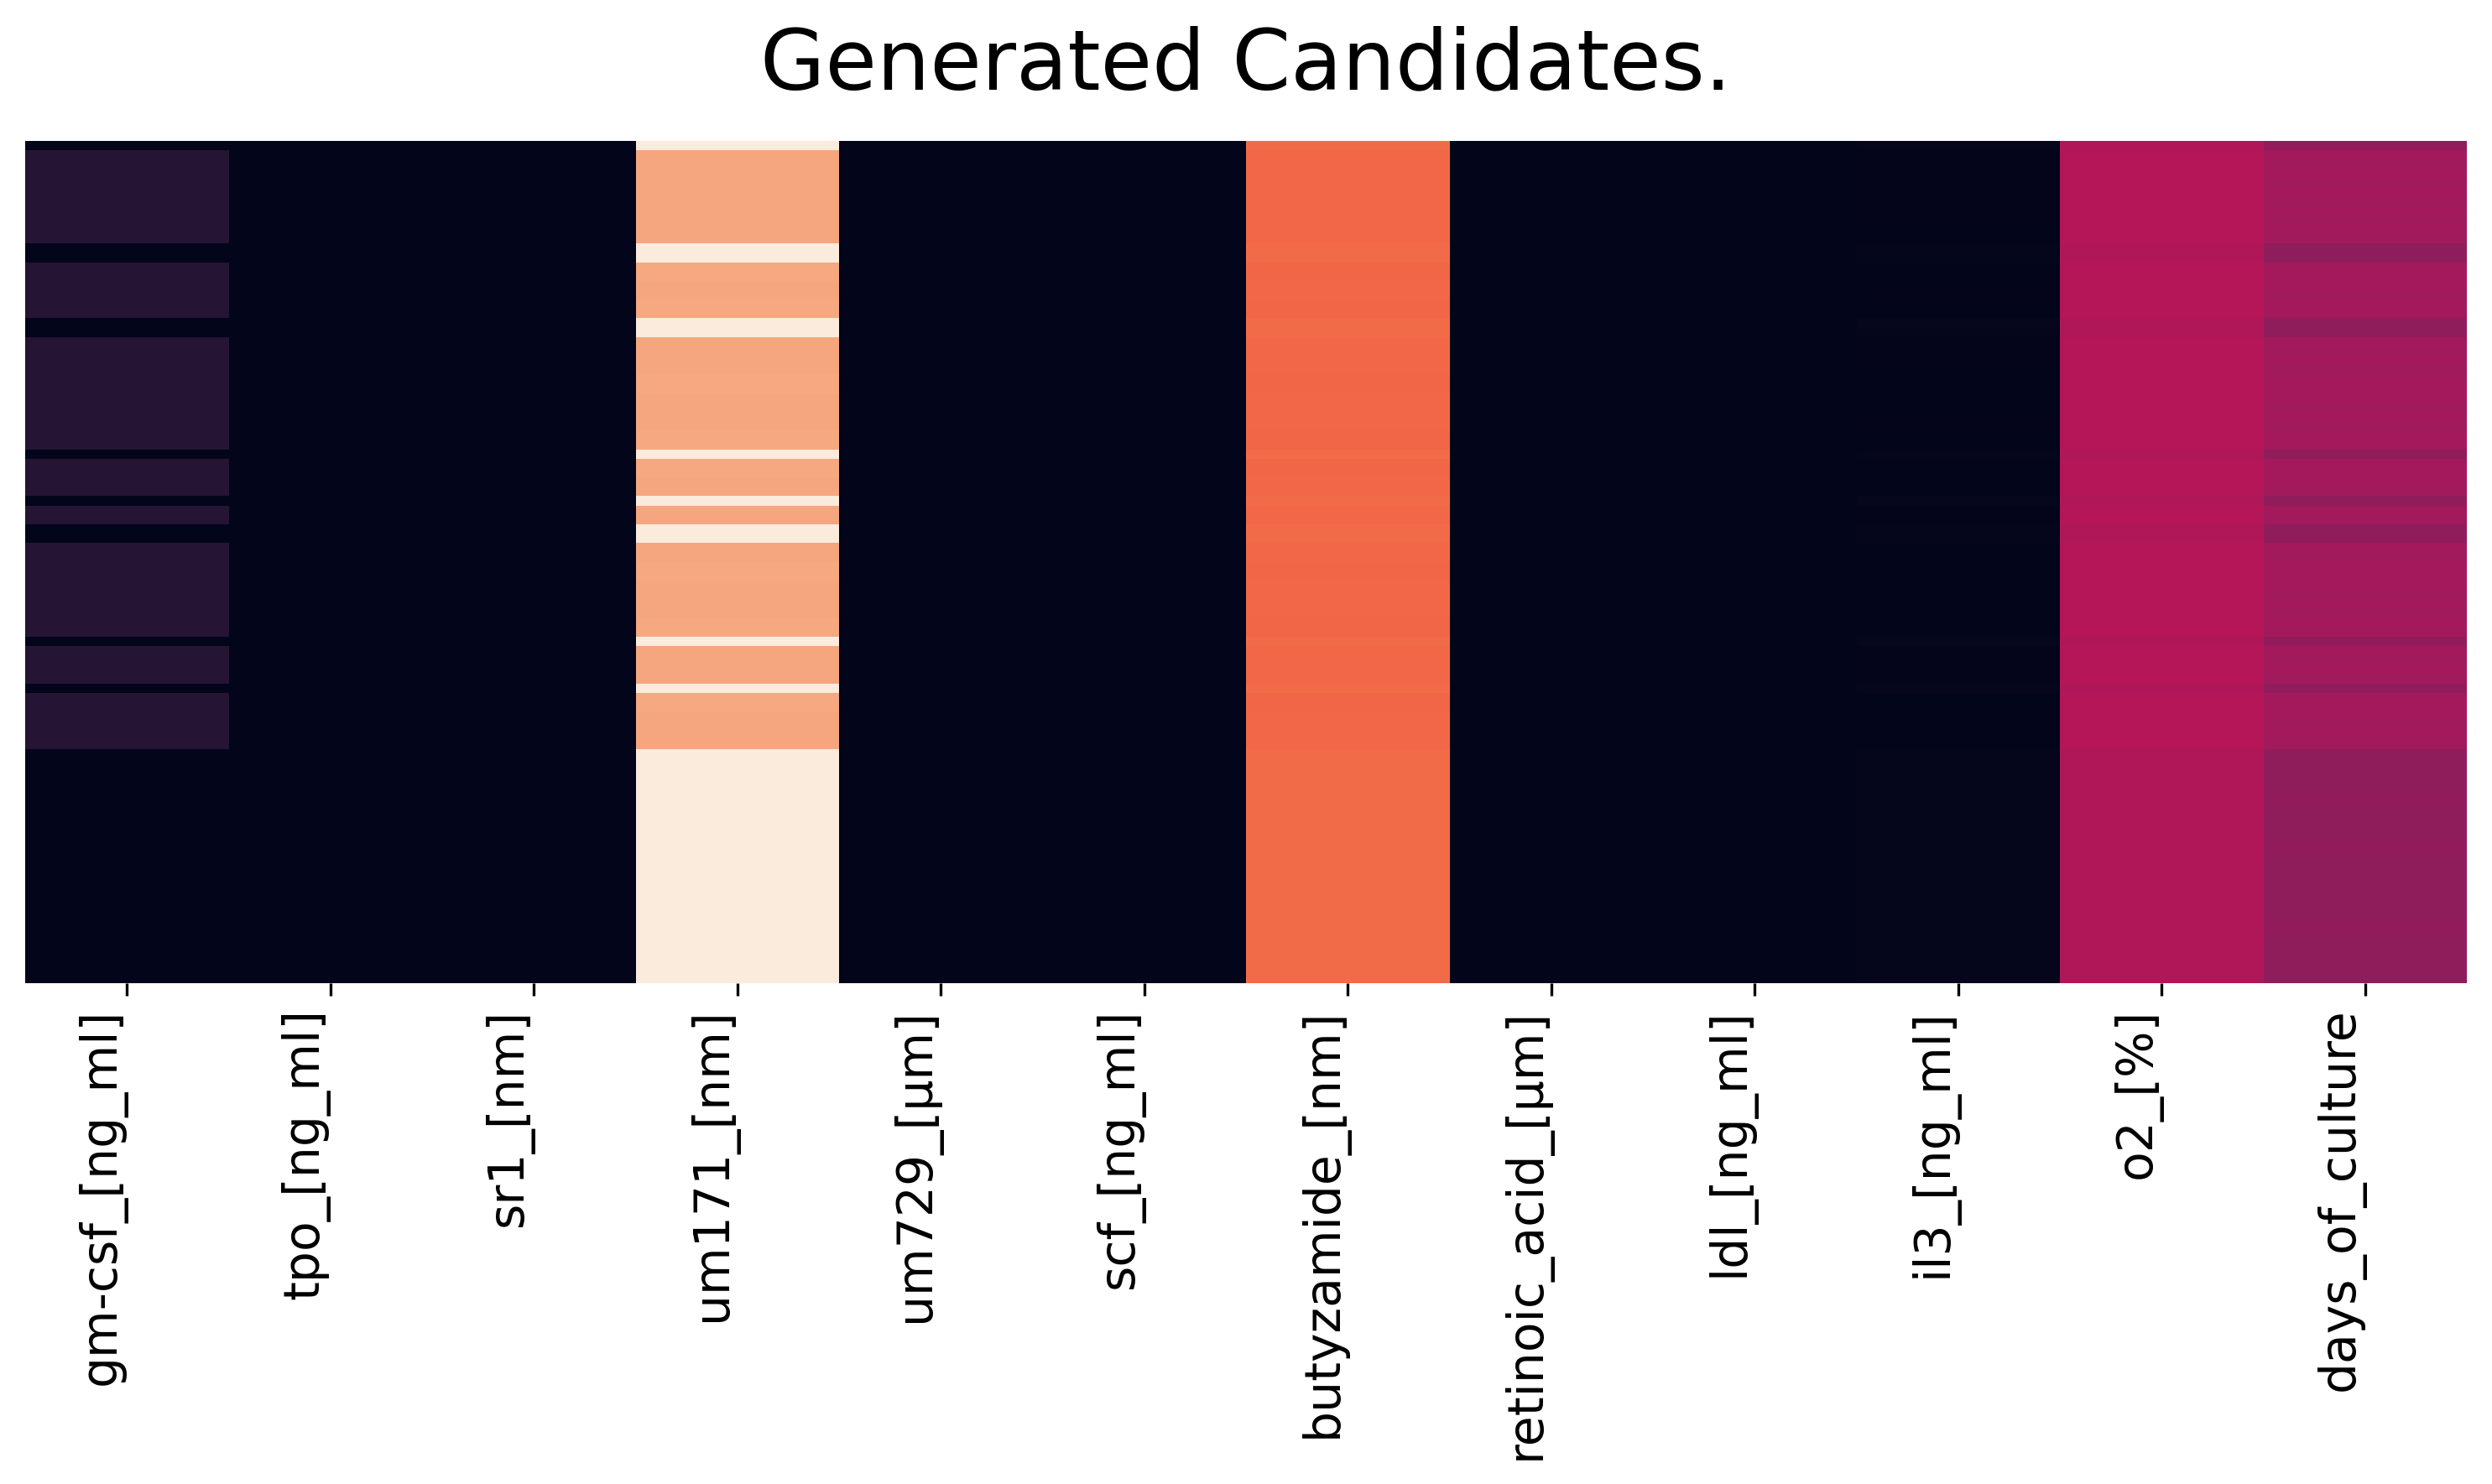

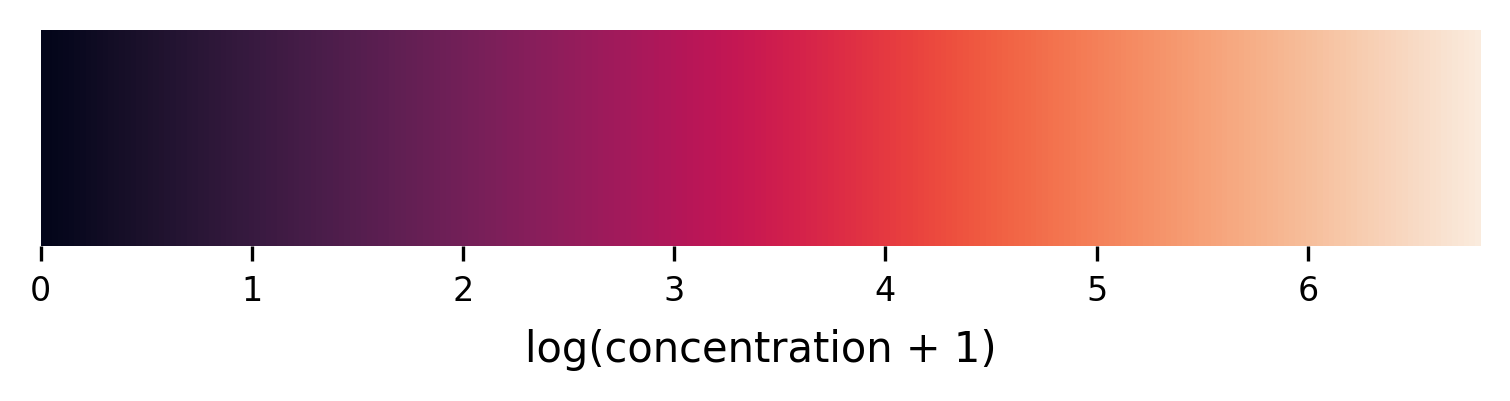

In [15]:
# ------------------------------------------------------------------
# 1. Prepare the data (unchanged)
# ------------------------------------------------------------------
filtered_candidates_df = candidates_df[candidates_df["passes_constraints:all"]]
mgk_enriching_mask = (filtered_candidates_df["late_MgkPro_prop"] > 0.15)
filtered_candidates_df = filtered_candidates_df[mgk_enriching_mask]
filtered_concs = filtered_candidates_df[protocol_cols].map(lambda e: math.log(e + 1))

# Determine global min/max for consistent colour scaling
vmin = filtered_concs.min().min()
vmax = filtered_concs.max().max()
cmap = 'rocket'  # or 'plasma', 'rocket', etc. – match your heatmap

# ------------------------------------------------------------------
# 2. Main heatmap (without colorbar)
# ------------------------------------------------------------------
plt.figure(figsize=(10, 6), dpi=300)
ax = sns.heatmap(
    filtered_concs,
    annot=False,
    fmt='.2f',
    linewidths=0.0,
    linecolor='black',
    cbar=False,               # disable the built‑in colorbar
    vmin=vmin, vmax=vmax,
    cmap=cmap
)

# Remove y‑axis ticks and labels
ax.set_yticklabels([])
ax.tick_params(axis='y', left=False)

# Rotate x‑labels
ax.set_xticklabels(ax.get_xticklabels(), rotation=90, ha='right', fontsize=14)

# Add title
plt.title('Generated Candidates.', fontsize=24, pad=15)

plt.tight_layout()
# plt.savefig('output/filtered_concentrations_heatmap_old_data.png', bbox_inches='tight', dpi=300)
plt.show()

# ------------------------------------------------------------------
# 3. Save the colorbar separately (fat and short, horizontal)
# ------------------------------------------------------------------
fig_cbar = plt.figure(figsize=(6, 1.2), dpi=300)   # wide and short
ax_cbar = fig_cbar.add_axes([0.1, 0.2, 0.8, 0.6])  # [left, bottom, width, height]

norm = Normalize(vmin=vmin, vmax=vmax)
sm = ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])

cbar = plt.colorbar(sm, cax=ax_cbar, orientation='horizontal')
cbar.set_label('log(concentration + 1)', fontsize=10, labelpad=5)
cbar.ax.tick_params(labelsize=8)

# Remove the frame around the colorbar axis
ax_cbar.set_frame_on(False)

# fig_cbar.savefig('output/heatma_colorbar_separate_old.png', bbox_inches='tight', dpi=300)
plt.show()


<Axes: xlabel='late_MgkPro_prop', ylabel='Count'>

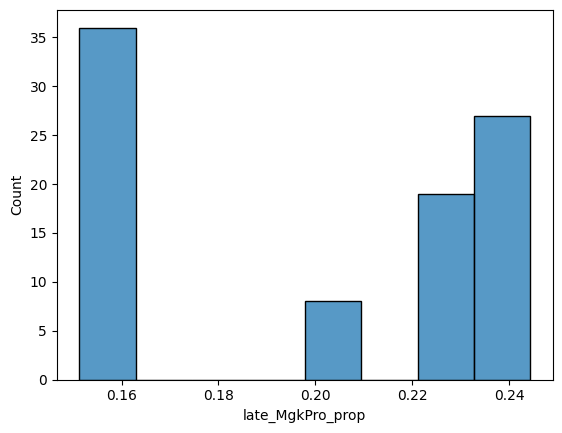

In [19]:
sns.histplot(filtered_candidates_df, x="late_MgkPro_prop")